In [10]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from scipy.spatial.distance import cdist # Nearest neighbor classification
import altair as alt
import random
from sklearn.decomposition import KernelPCA
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
def load_yale_faces(path):
    """Load all Yale faces, grouped by person"""
    persons = {}
    for folder in sorted(os.listdir(path)):
        folder_path = os.path.join(path, folder)
        if os.path.isdir(folder_path):
            imgs = []
            for f in sorted(os.listdir(folder_path)):
                filepath = os.path.join(folder_path, f)
                if os.path.isfile(filepath):
                    try:
                        img = Image.open(filepath)
                        imgs.append(np.array(img, dtype=np.float64))
                    except Exception:
                        pass
            if imgs:
                persons[folder] = imgs
    return persons

def split_data(persons, n_train, seed=42):
    """
    Split data: randomly select n_train images for training per person,
    then randomly select 1 image from the remaining as test.
    """
    random.seed(seed)
    train_imgs, train_labels = [], []
    test_imgs, test_labels = [], []

    for label, imgs in persons.items():
        if len(imgs) <= n_train:
            raise ValueError(
                f"Person '{label}' has only {len(imgs)} images, "
                f"need at least {n_train + 1} (n_train={n_train} + 1 for test)."
            )
        indices = list(range(len(imgs)))
        random.shuffle(indices)

        # First n_train shuffled indices -> training
        train_indices = indices[:n_train]
        # From remaining, randomly pick 1 -> test
        remaining = indices[n_train:]
        test_index = random.choice(remaining)

        for i in train_indices:
            train_imgs.append(imgs[i])
            train_labels.append(label)

        test_imgs.append(imgs[test_index])
        test_labels.append(label)

    return train_imgs, train_labels, test_imgs, test_labels

# Load data
persons = load_yale_faces("Datasets/yalefaces")
print(f"Number of persons: {len(persons)}")
# for label, imgs in persons.items():
#    print(f"  {label}: {len(imgs)} images, size {imgs[0].shape}")

n_train = 4  # number of training images per person

train_imgs, train_labels, test_imgs, test_labels = split_data(persons, n_train=n_train)

X_train = np.array([img.flatten() for img in train_imgs])
X_test = np.array([img.flatten() for img in test_imgs])
y_train = np.array(train_labels)
y_test = np.array(test_labels)

n_imgs_per_person = len(next(iter(persons.values())))
print(f"\nn_train = {n_train}, n_test = 1 (selected from remaining {n_imgs_per_person - n_train})")
print(f"Training set: {X_train.shape[0]} images")
print(f"Test set: {X_test.shape[0]} images")
print(f"Feature dimension: {X_train.shape[1]}")

print(f"Image size: {train_imgs[0].shape}")
print(f"Training matrix: {X_train.shape}, Test matrix: {X_test.shape}")

# Visualize some training samples
fig, axes = plt.subplots(3, 5, figsize=(15, 4))
for i, ax in enumerate(axes.flatten()):
    if i < len(train_imgs):
        ax.imshow(train_imgs[i], cmap='gray')
        ax.set_title(f"{train_labels[i]}", fontsize=8)
    ax.axis('off')
plt.suptitle("Training Samples")
plt.tight_layout()
plt.show()

# Visualize some test samples
fig, axes = plt.subplots(3, 5, figsize=(15, 4))
for i, ax in enumerate(axes.flatten()):
    if i < len(test_imgs):
        ax.imshow(test_imgs[i], cmap='gray')
        ax.set_title(f"{test_labels[i]}", fontsize=8)
    ax.axis('off')
plt.suptitle("Test Samples")
plt.tight_layout()
plt.show()

In [ ]:
# ====================================================================
# [Demo] Compute Training Kernel Matrix (RBF)
# NOTE: Standalone demonstration of kernel computation.
#       The full KPCA pipeline below handles this automatically.
# ====================================================================
gamma = 1e-7

# K[i, j] = exp(-gamma * ||x_i - x_j||^2)
X_sq = np.sum(X_train ** 2, axis=1, keepdims=True)
dist_sq = X_sq + X_sq.T - 2 * X_train @ X_train.T
K_train = np.exp(-gamma * dist_sq)

print(f"Training kernel matrix shape: {K_train.shape}")

In [ ]:
# ====================================================================
# [Demo] Center the Kernel Matrix
# K_c = K - 1_N K - K 1_N + 1_N K 1_N
# NOTE: Standalone demonstration. The full KPCA pipeline handles this automatically.
# ====================================================================
N = K_train.shape[0]
one_N = np.ones((N, N)) / N

K_centered = K_train - one_N @ K_train - K_train @ one_N + one_N @ K_train @ one_N

print(f"Centered kernel matrix shape: {K_centered.shape}")
print(f"Row mean (should ≈ 0): {np.abs(K_centered.mean(axis=1)).max():.2e}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(K_train, cmap='viridis', aspect='auto')
axes[0].set_title(f"Original K (RBF, γ={gamma})")
axes[0].set_xlabel("Training sample index")
axes[0].set_ylabel("Training sample index")
plt.colorbar(axes[0].images[0], ax=axes[0])

axes[1].imshow(K_centered, cmap='RdBu_r', aspect='auto')
axes[1].set_title("Centered K")
axes[1].set_xlabel("Training sample index")
plt.colorbar(axes[1].images[0], ax=axes[1])

plt.tight_layout()
plt.show()

Number of persons: 15
n_train =  1 | max_k =  15 | best accuracy = 53.33% at k = 14
n_train =  2 | max_k =  30 | best accuracy = 60.00% at k = 29
n_train =  3 | max_k =  45 | best accuracy = 80.00% at k = 44
n_train =  4 | max_k =  60 | best accuracy = 80.00% at k = 58
n_train =  5 | max_k =  75 | best accuracy = 80.00% at k = 72
n_train =  6 | max_k =  90 | best accuracy = 73.33% at k = 88
n_train =  7 | max_k = 105 | best accuracy = 66.67% at k = 101
n_train =  8 | max_k = 120 | best accuracy = 93.33% at k = 113
n_train =  9 | max_k = 135 | best accuracy = 93.33% at k = 128
n_train = 10 | max_k = 150 | best accuracy = 86.67% at k = 142


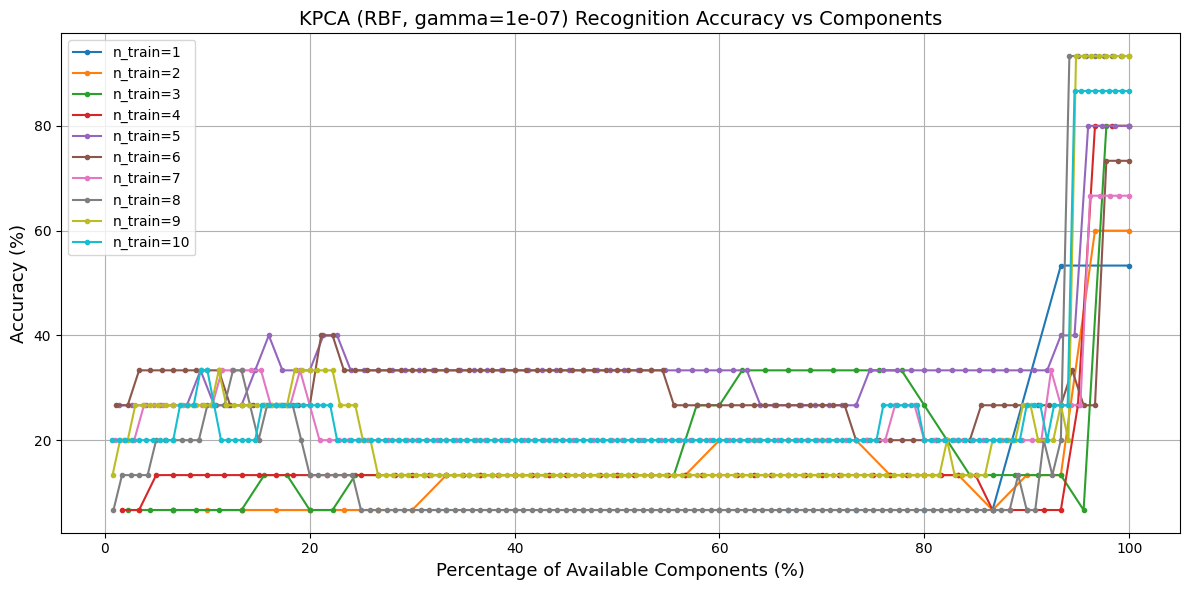

In [13]:
# ====================================================================
# 3. Kernel Functions
# ====================================================================
def rbf_kernel(X, Y, gamma):
    """Compute RBF (Gaussian) kernel matrix between X and Y"""
    # ||x - y||^2 = ||x||^2 + ||y||^2 - 2 * x.y
    X_sq = np.sum(X ** 2, axis=1).reshape(-1, 1)
    Y_sq = np.sum(Y ** 2, axis=1).reshape(1, -1)
    dist_sq = X_sq + Y_sq - 2 * X @ Y.T
    return np.exp(-gamma * dist_sq)

def poly_kernel(X, Y, degree=3, coef0=1):
    """Compute polynomial kernel matrix between X and Y"""
    return (X @ Y.T + coef0) ** degree

def sigmoid_kernel(X, Y, gamma=0.001, coef0=0):
    """Compute sigmoid kernel matrix between X and Y"""
    return np.tanh(gamma * (X @ Y.T) + coef0)

# ====================================================================
# 4. KPCA Class
# ====================================================================
class KernelPCA:
    def __init__(self, kernel_fn, n_components=None):
        self.kernel_fn = kernel_fn
        self.n_components = n_components

    def fit(self, X):
        """Fit KPCA on training data"""
        self.X_train = X
        N = X.shape[0]

        # Compute kernel matrix
        K = self.kernel_fn(X, X)

        # Center kernel matrix in feature space
        one_N = np.ones((N, N)) / N
        K_centered = K - one_N @ K - K @ one_N + one_N @ K @ one_N
        self.K_train = K
        self.K_centered = K_centered

        # Eigendecomposition
        eigenvalues, eigenvectors = np.linalg.eigh(K_centered)

        # Sort by descending eigenvalue
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        # Keep only positive eigenvalues
        pos_mask = eigenvalues > 1e-10
        eigenvalues = eigenvalues[pos_mask]
        eigenvectors = eigenvectors[:, pos_mask]

        # Normalize eigenvectors: alpha / sqrt(lambda)
        self.alphas = eigenvectors / np.sqrt(eigenvalues)
        self.eigenvalues = eigenvalues

        if self.n_components is not None:
            self.alphas = self.alphas[:, :self.n_components]
            self.eigenvalues = self.eigenvalues[:self.n_components]

        return self

    def transform(self, X):
        """Project data onto KPCA components"""
        K_test = self.kernel_fn(X, self.X_train)
        N_train = self.X_train.shape[0]
        N_test = X.shape[0]

        # Center test kernel matrix
        one_N_train = np.ones((N_train, N_train)) / N_train
        one_N_test = np.ones((N_test, N_train)) / N_train

        K_test_centered = (
            K_test
            - one_N_test @ self.K_train
            - K_test @ one_N_train
            + one_N_test @ self.K_train @ one_N_train
        )

        return K_test_centered @ self.alphas

    def fit_transform(self, X):
        self.fit(X)
        return self.K_centered @ self.alphas

# ====================================================================
# 5. 1-NN Classifier
# ====================================================================
def nearest_neighbor_classify(X_train_proj, y_train, X_test_proj):
    """Simple 1-NN classifier using Euclidean distance"""
    predictions = []
    for test_sample in X_test_proj:
        dists = np.linalg.norm(X_train_proj - test_sample, axis=1)
        nearest_idx = np.argmin(dists)
        predictions.append(y_train[nearest_idx])
    return np.array(predictions)

# ====================================================================
# 6. Main Experiment
# ====================================================================
persons = load_yale_faces("Datasets/yalefaces")
print(f"Number of persons: {len(persons)}")

# --- Experiment: vary n_train and n_components ---
n_train_list = list(range(1, 11))  # 1 to 10
gamma = 1e-7  # RBF gamma (tune this for your image size)

accuracy_data = {}

for n_tr in n_train_list:
    train_imgs, train_labels, test_imgs, test_labels = split_data(persons, n_train=n_tr)

    X_train = np.array([img.flatten() for img in train_imgs])
    X_test = np.array([img.flatten() for img in test_imgs])
    y_train = np.array(train_labels)
    y_test = np.array(test_labels)

    max_k = X_train.shape[0]  # max components = number of training samples
    kernel_fn = lambda X, Y: rbf_kernel(X, Y, gamma=gamma)

    kpca = KernelPCA(kernel_fn=kernel_fn, n_components=None)
    X_train_proj = kpca.fit_transform(X_train)
    X_test_proj = kpca.transform(X_test)

    k_list = list(range(1, max_k + 1))
    acc_list = []

    for k in k_list:
        preds = nearest_neighbor_classify(
            X_train_proj[:, :k], y_train, X_test_proj[:, :k]
        )
        acc = np.mean(preds == y_test) * 100
        acc_list.append(acc)

    best_acc = max(acc_list)
    best_k = k_list[acc_list.index(best_acc)]
    accuracy_data[n_tr] = {
        'k_list': k_list,
        'accuracy': acc_list,
        'best_acc': best_acc,
        'best_k': best_k
    }
    print(f"n_train = {n_tr:2d} | max_k = {max_k:3d} | "
          f"best accuracy = {best_acc:.2f}% at k = {best_k}")

# ====================================================================
# 7. Plot Accuracy Curves
# ====================================================================
plt.figure(figsize=(12, 6))
for n_tr in n_train_list:
    k_list = accuracy_data[n_tr]['k_list']
    max_k = k_list[-1]
    k_pct = [k / max_k * 100 for k in k_list]
    plt.plot(k_pct, accuracy_data[n_tr]['accuracy'],
             label=f"n_train={n_tr}", marker='o', markersize=3)

plt.xlabel("Percentage of Available Components (%)", fontsize=13)
plt.ylabel("Accuracy (%)", fontsize=13)
plt.title(f"KPCA (RBF, gamma={gamma}) Recognition Accuracy vs Components", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()